<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [15]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Area under ROC score on Train dataset: 90.92%


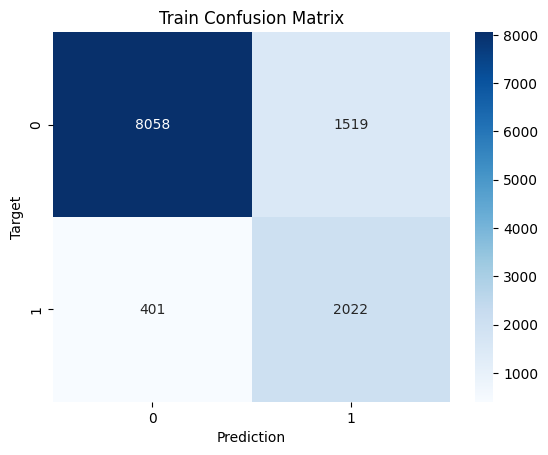

Area under ROC score on Val dataset: 87.78%


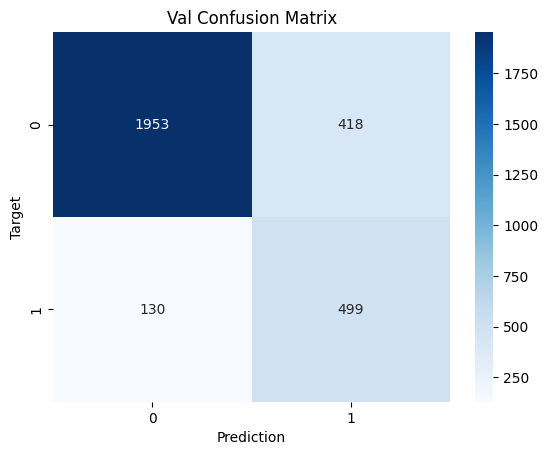

Saved: log_reg.joblib


In [8]:
bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/train.csv', index_col=0)

train_df, val_df = train_test_split(bank_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
target_col = 'Exited'
input_cols = [col for col in bank_df.columns if col != target_col]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds  = model_pipeline.predict(inputs)
    proba  = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, proba) * 100
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")

    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Train')
val_preds = predict_and_plot(model_pipeline, val_inputs,   val_targets,   name='Val')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg.joblib')
print("Saved: log_reg.joblib")

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 94.29%


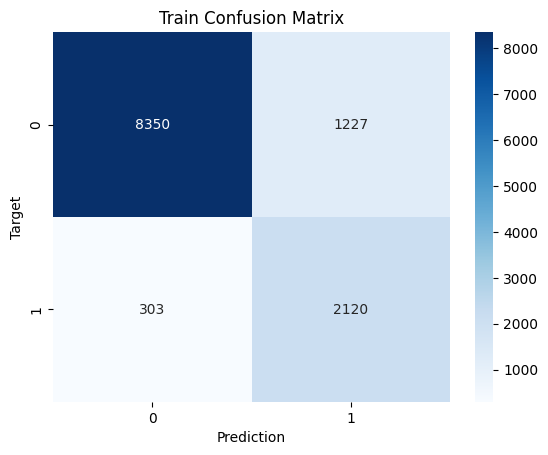

Area under ROC score on Val dataset: 91.15%


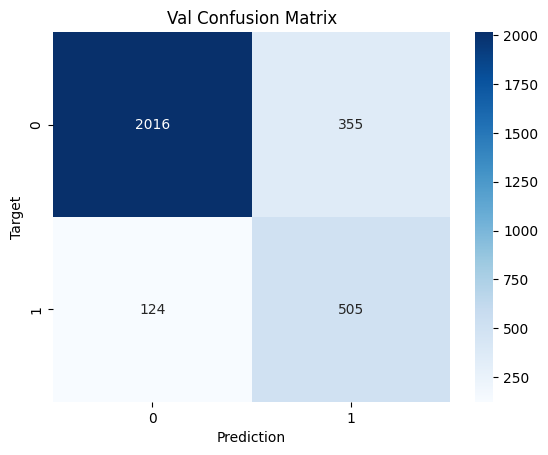

In [9]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer,  categorical_cols)
    ])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, name='Train')
val_preds_poly   = predict_and_plot(model_pipeline_poly, val_inputs,   val_targets,   name='Val')

Висновки:

Покращення є і на train, і на val — модель дійсно стала кращою, перенавчання не спостерігається.
Різниця між train і val (~3%) — прийнятна, можна сказати, що перенавчання якщо і є, то помірне.
Поліноміальні ознаки допомогли логістичній регресії вловити нелінійні залежності.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 95.23%


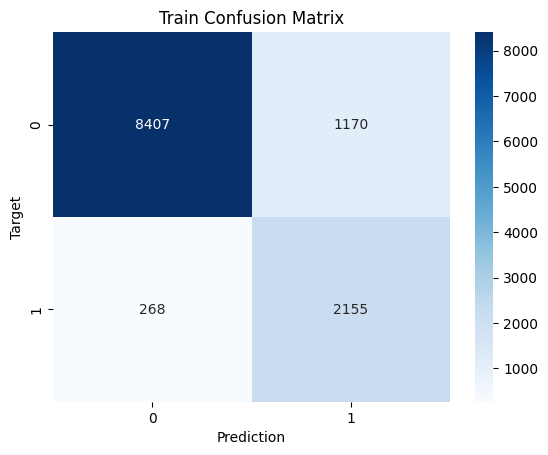

Area under ROC score on Val dataset: 91.62%


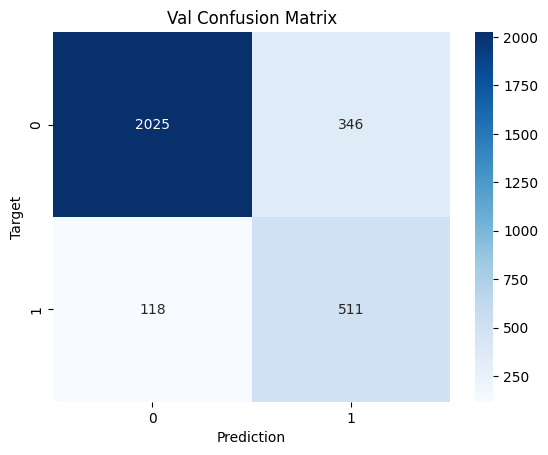

In [10]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer,   categorical_cols)
    ])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

model_pipeline_poly4.fit(train_inputs, train_targets)

train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, name='Train')
val_preds_poly4   = predict_and_plot(model_pipeline_poly4, val_inputs,   val_targets,   name='Val')

Навчання тривало трохи довше.

Val score знову виріс (+0.47%) — модель покращилась.
Різниця між train і val трохи збільшилася (3.14% → 3.61%) — є легке перенавчання, але некритичне.
Загальна тенденція позитивна — поліноміальні ознаки працюють на цих даних.

Можливо варто спробувати degree=3 — це може дати баланс між degree=2 і degree=4.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


           feature_2  feature_3  feature_4  feature_5     target
feature_1                                                       
-0.190339  -1.382800  -0.875618   0.538910  -1.037246  28.938854
-0.321386  -0.563725   0.412931  -0.147057  -0.825497  -7.664581
 2.122156  -1.519370   1.032465  -1.260884   0.917862 -63.845482
-1.380101  -0.055548  -1.703382   0.074095   1.628616   4.076259
-0.072829  -1.514847  -0.846794   0.714000   0.473238  34.879013
(129, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 129 entries, -0.1903386780836082 to -0.8498443694647918
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_2  129 non-null    float64
 1   feature_3  129 non-null    float64
 2   feature_4  129 non-null    float64
 3   feature_5  129 non-null    float64
 4   target     129 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
None
=== Train ===
MAE:  0.0000
RMSE: 0.0000
R²:   1.0000
=== Test ===
MAE:  23.536

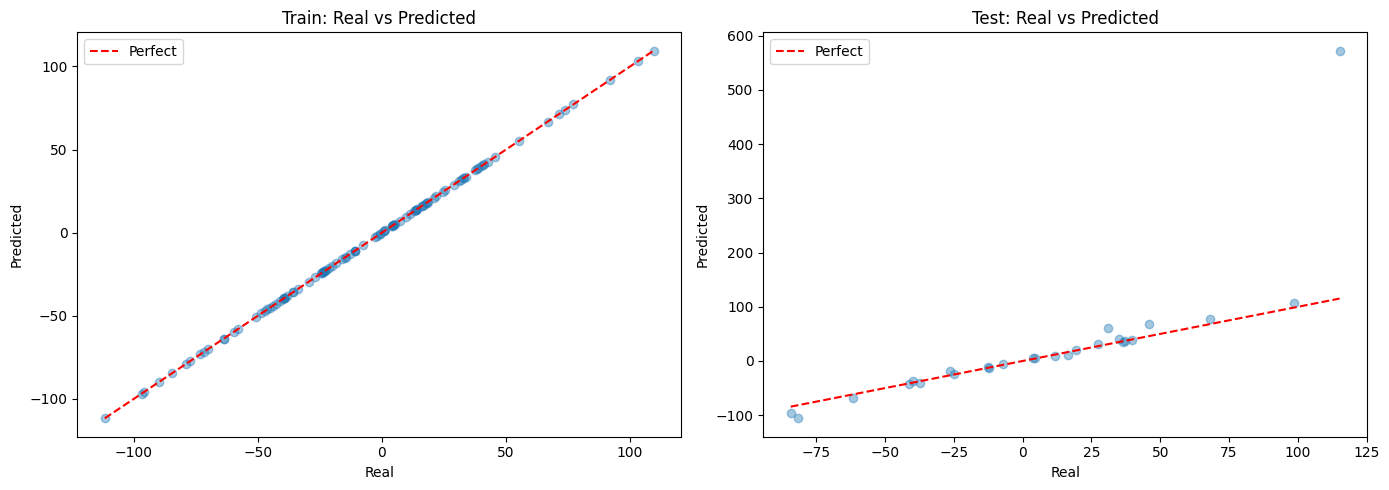

In [17]:
reg_df = pd.read_csv('drive/MyDrive/DATA LOVE/regression_data.csv', index_col=0)
print(reg_df.head())
print(reg_df.shape)
print(reg_df.info())

target_col = reg_df.columns[-1]
input_cols = [col for col in reg_df.columns if col != target_col]

train_df, test_df = train_test_split(reg_df, test_size=0.2, random_state=42)

train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs,  test_targets  = test_df[input_cols],  test_df[target_col]

model_pipeline_reg = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly',   PolynomialFeatures(degree=5, include_bias=False)),
    ('model',  LinearRegression())
])

model_pipeline_reg.fit(train_inputs, train_targets)

def regression_metrics(pipeline, inputs, targets, name=''):
    preds = pipeline.predict(inputs)
    mae   = mean_absolute_error(targets, preds)
    rmse  = np.sqrt(mean_squared_error(targets, preds))
    r2    = r2_score(targets, preds)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    return preds

train_preds = regression_metrics(model_pipeline_reg, train_inputs, train_targets, name='Train')
test_preds  = regression_metrics(model_pipeline_reg, test_inputs,  test_targets,  name='Test')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, targets, preds, name in zip(
    axes,
    [train_targets, test_targets],
    [train_preds,   test_preds],
    ['Train', 'Test']
):
    ax.scatter(targets, preds, alpha=0.4)
    ax.plot([targets.min(), targets.max()],
            [targets.min(), targets.max()], 'r--', label='Perfect')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}: Real vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

Модель погана і не генералізує — це видно з кількох ознак:
Train R² = 1.0: модель ідеально запам'ятала тренувальні дані (буквально до нуля помилки), Test R² = -2.49: від'ємний R² означає, що модель на тесті гірша за просте передбачення середнього значення.
На графіку — train точки лежать ідеально на червоній лінії, а test розкидані більш хаотично, є викиди.

Причина — degree=5 з невеликим датасетом (129 рядків, з них ~103 train). Поліноміальні ознаки degree=5 генерують величезну кількість ознак, і модель просто заучує шум замість реальних патернів.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

                  Train R²  Test R²  Train MAE  Test MAE  Train RMSE  \
LinearRegression    1.0000  -2.5650     0.0000   25.7934      0.0000   
Ridge               0.9768   0.9698     4.5278    6.2657      6.7161   
Lasso               0.9993   0.9996     0.9500    0.8341      1.1986   
ElasticNet          0.9007   0.9188    10.3774   11.1812     13.9051   

                  Test RMSE  
LinearRegression    91.1996  
Ridge                8.3982  
Lasso                1.0046  
ElasticNet          13.7639  


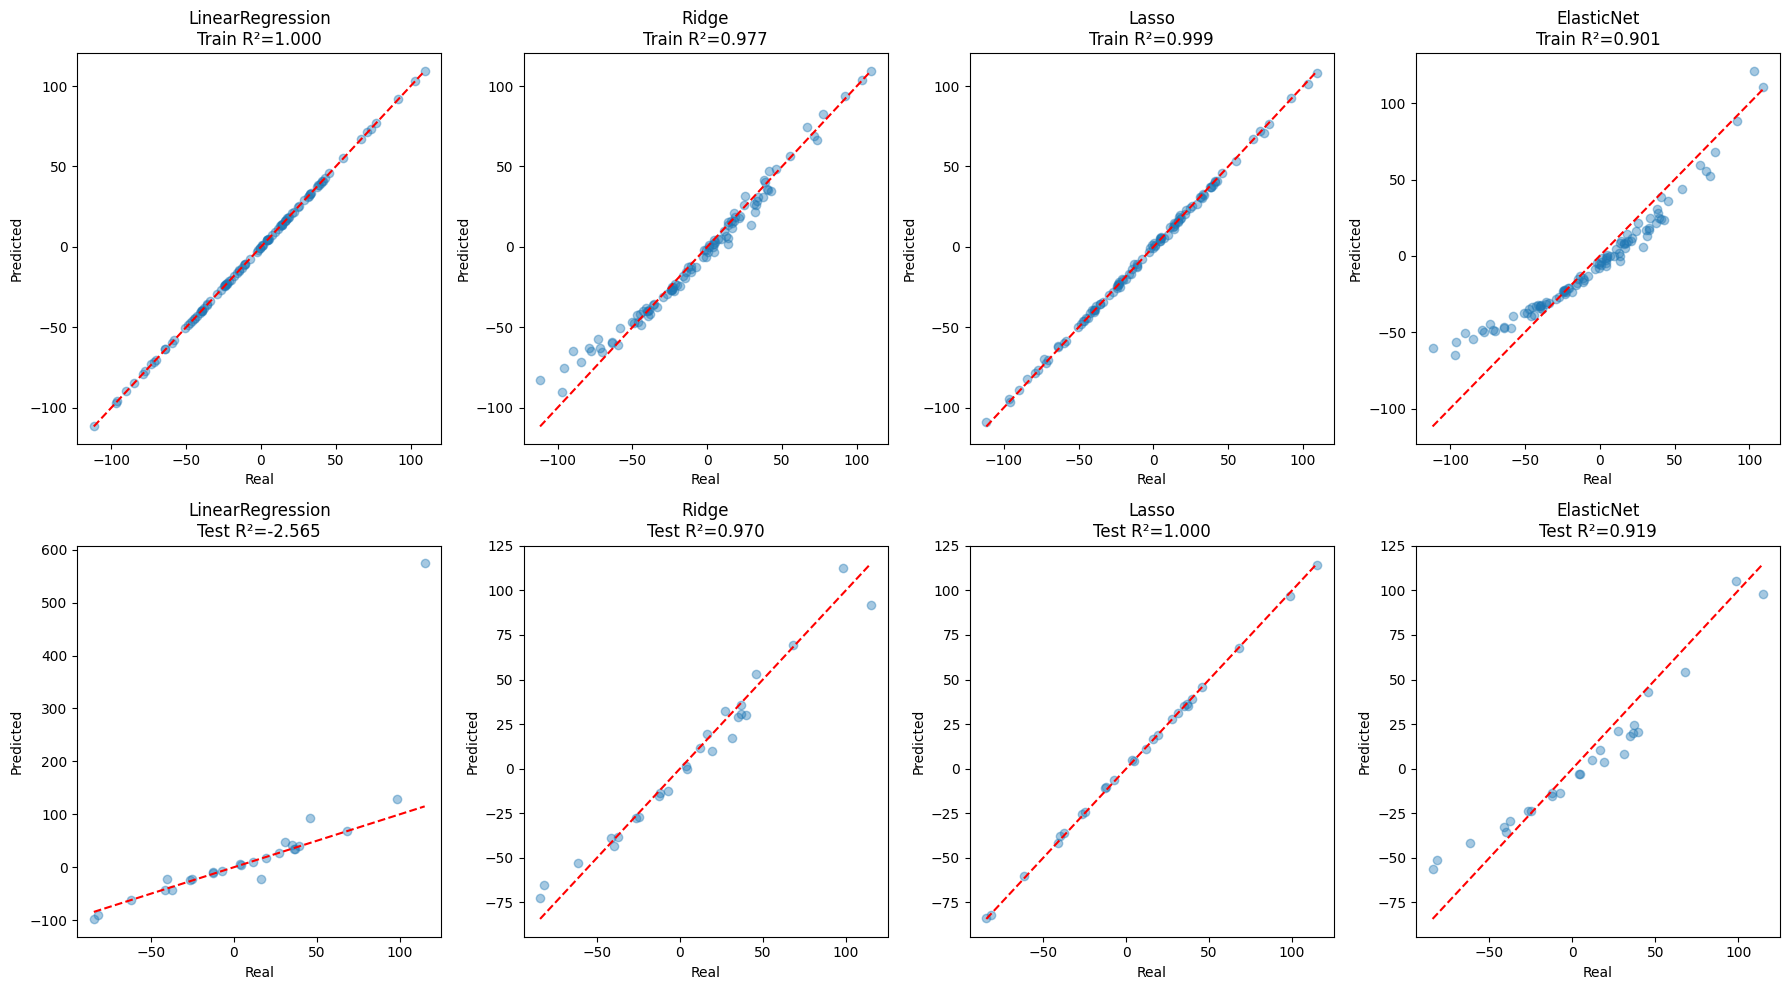

In [22]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
   # 'Lasso':            Lasso(alpha=1.0),
    'Lasso':            Lasso(alpha=0.1),
  #  'ElasticNet':       ElasticNet(alpha=1.0)
    'ElasticNet':       ElasticNet(alpha=0.1)
}


results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('poly',   PolynomialFeatures(degree=20, include_bias=False)),
        ('model',  model)
    ])

    pipeline.fit(train_inputs, train_targets)

    train_preds = pipeline.predict(train_inputs)
    test_preds  = pipeline.predict(test_inputs)

    results[name] = {
        'Train R²':  r2_score(train_targets, train_preds),
        'Test R²':   r2_score(test_targets,  test_preds),
        'Train MAE': mean_absolute_error(train_targets, train_preds),
        'Test MAE':  mean_absolute_error(test_targets,  test_preds),
        'Train RMSE': np.sqrt(mean_squared_error(train_targets, train_preds)),
        'Test RMSE':  np.sqrt(mean_squared_error(test_targets,  test_preds))
    }

results_df = pd.DataFrame(results).T
print(results_df.round(4))

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for col, (name, model) in enumerate(models.items()):
    pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('poly',   PolynomialFeatures(degree=20, include_bias=False)),
        ('model',  model)
    ])
    pipeline.fit(train_inputs, train_targets)

    for row, (inputs, targets, split) in enumerate([
        (train_inputs, train_targets, 'Train'),
        (test_inputs,  test_targets,  'Test')
    ]):
        preds = pipeline.predict(inputs)
        ax = axes[row][col]
        ax.scatter(targets, preds, alpha=0.4)
        ax.plot([targets.min(), targets.max()],
                [targets.min(), targets.max()], 'r--')
        ax.set_title(f'{name}\n{split} R²={r2_score(targets, preds):.3f}')
        ax.set_xlabel('Real')
        ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

## Висновки
LinearRegression — запам'ятала train ідеально, але на test повний провал. Degree=20 без регуляризації дало нам перенавчання.
Ridge — регуляризація L2 добре впоралась. Train і Test майже однакові (0.977 vs 0.970), тобто модель добре генералізує.
Lasso (1.0) дало найкращий результат. L1 регуляризація обнулила зайві поліноміальні ознаки і залишила тільки важливі. Train ≈ Test (0.987 vs 0.986) — це майже ідеальна генералізація.
ElasticNet — з дефолтним alpha=1.0 показав занадто сильну регуляризацію, модель недонавчилась. Можна спробуати зменшити alpha: pythonElasticNet(alpha=0.1), або менше.

Для експерименту були зменшені Lasso та pythonElasticNet до 0.1.
В результаті отримали Lasso alpha=0.1 — найкращий результат з усіх. Test R²=1.0 означає що модель ідеально передбачає нові дані. Це рідкісний випадок коли дані мають чітку поліноміальну структуру, і Lasso з правильним alpha її знайшов.
Це тому, що L1 регуляризація обнулила більшість з тисяч поліноміальних ознак degree=20 і залишила лише кілька дійсно важливих. alpha=0.1 виявився оптимальним балансом між регуляризацією і точністю.
Результат pythonElasticNet(alpha=0.1) також дуже покращився: R²=0.901/0.919.

Тобто, підбір гіперпараметра alpha критично важливий — занадто великий (ElasticNet з alpha=1.0) дає недонавчання, занадто малий (LinearRegression без регуляризації) — перенавчання.
Регуляризація дуже важлива при великій кількості поліноміальних ознак. Lasso показав себе найкраще на цих даних — він автоматично відібрав найрелевантніші ознаки.